# 0 · Descarga y exploración inicial de datos

> **Proyecto:** `ClimaSafeAI`  
> **Tipo de ML:** `supervisado`  
> **Autor:** `Alejandro Cancelas Chapela`


## 1. Imports y configuración

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import missingno as msno
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import os
from dotenv import load_dotenv
from climasafeai.utils.paths import RAW_DATA_DIR, FIGURES_DIR
from climasafeai.data.make_dataset import load_data, download_era5_data, dataset_calor, cargar_era5_filtrado, download_momo_data, cargar_provincias_unificadas, calcular_puntos_provincia  
import xarray as xr

# ── Estilo global ────────────────────────────────────S─────────────────────
plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(' Imports OK')


 Imports OK


**Resumen:** Imports correctos y directorio de `FIGURES_DIR` creado. Si hay dependencias faltantes, las fallas aparecerán en celdas posteriores al ejecutar el notebook.

## 2. Carga de datos

Coloca el CSV en `data/raw/` y ajusta `DATA_FILE` y `TARGET_COL`.

In [2]:
load_dotenv()

download_momo_data()
download_era5_data()

    momo_data.csv ya existe en /home/cacelas/Documentos/anfaia/ClimaSafeAI/data/raw
    era5_2016_01.nc ya existe.
    era5_2016_02.nc ya existe.
    era5_2016_03.nc ya existe.
    era5_2016_04.nc ya existe.
    era5_2016_05.nc ya existe.
    era5_2016_06.nc ya existe.
    era5_2016_07.nc ya existe.
    era5_2016_08.nc ya existe.
    era5_2016_09.nc ya existe.
    era5_2016_10.nc ya existe.
    era5_2016_11.nc ya existe.
    era5_2016_12.nc ya existe.
    era5_2017_01.nc ya existe.
    era5_2017_02.nc ya existe.
    era5_2017_03.nc ya existe.
    era5_2017_04.nc ya existe.
    era5_2017_05.nc ya existe.
    era5_2017_06.nc ya existe.
    era5_2017_07.nc ya existe.
    era5_2017_08.nc ya existe.
    era5_2017_09.nc ya existe.
    era5_2017_10.nc ya existe.
    era5_2017_11.nc ya existe.
    era5_2017_12.nc ya existe.
    era5_2018_01.nc ya existe.
    era5_2018_02.nc ya existe.
    era5_2018_03.nc ya existe.
    era5_2018_04.nc ya existe.
    era5_2018_05.nc ya existe.
    era5_2018_06.

**Resumen:** Las descargas de datos ya existen en `data/raw` (ERA5 y MOMO). No fue necesario descargar archivos nuevos.

In [ ]:
provincias = cargar_provincias_unificadas()
puntos_por_provincia = calcular_puntos_provincia(provincias, col_nombre="NAMEUNIT")
df_eras = cargar_era5_filtrado(puntos_por_provincia)

--> Cargando y filtrando 126 archivos ERA5...


**Resumen:** Se han cargado y filtrado los archivos ERA5 (126 archivos). El proceso parece completarse sin errores.

In [ ]:
df_eras.head(3)

<xarray.Dataset> Size: 908B
Dimensions:     (valid_time: 3, punto: 3)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 24B 2016-01-01 ... 2016-01-01T02:...
    expver      (valid_time) <U4 48B '0001' '0001' '0001'
    latitude    (punto) float64 24B 43.25 43.75 42.5
    longitude   (punto) float64 24B -8.5 -7.75 -9.0
    provincia   (punto) <U44 528B 'A Coruña' 'A Coruña' 'A Coruña'
    tipo_punto  (punto) <U6 72B 'centro' 'norte' 'sur'
    number      int64 8B 0
Dimensions without coordinates: punto
Data variables:
    t2m         (valid_time, punto) float32 36B 284.2 285.4 ... 285.5 285.7
    d2m         (valid_time, punto) float32 36B 280.5 280.6 ... 280.1 282.0
    sp          (valid_time, punto) float32 36B 9.955e+04 ... 1.013e+05
    u10         (valid_time, punto) float32 36B -0.7338 0.4088 ... -0.9486
    v10         (valid_time, punto) float32 36B 6.08 5.216 7.805 ... 5.451 9.202
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-02T11:29 GRIB to CDM+CF via cfgrib-0.9.1...

**Interpretación:** `df_eras` es un `xarray.Dataset` con las coordenadas y variables esperadas (`t2m`, `d2m`, `sp`, `u10`, `v10`). Muestra 3 tiempos y 3 puntos en el `head` — sirve como comprobación de carga correcta de un subconjunto.

In [ ]:
DATA_FILE = RAW_DATA_DIR / "momo_data.csv"
TARGET_COL = "defunciones_atrib_exc_temp"
try:
    df_momo = load_data(DATA_FILE)
except FileNotFoundError:
    raise FileNotFoundError(
        f"Archivo no encontrado: {DATA_FILE}\n"
        "Coloca el CSV en data/raw/ y ajusta DATA_FILE arriba."
    )
df_momo.head(10)


--> Cargando datos desde /home/cacelas/Documentos/anfaia/ClimaSafeAI/data/raw/momo_data.csv...
    Datos cargados. Dimensiones: (7257600, 15)


,ambito,cod_ambito,cod_ine_ambito,nombre_ambito,cod_sexo,nombre_sexo,cod_gedad,nombre_gedad,fecha_defuncion,defunciones_observadas,defunciones_estimadas_base,defunciones_estimadas_base_q01,defunciones_estimadas_base_q99,defunciones_atrib_exc_temp,defunciones_atrib_def_temp
0,ccaa,AN,1.000,Andalucía,1,hombres,+65,edad >= 65,2015-01-01,108.880,83.250,63.000,105.000,0.000,5.500
1,ccaa,AN,1.000,Andalucía,1,hombres,+85,edad >= 85,2015-01-01,35.570,27.390,16.000,40.000,0.000,1.610
2,ccaa,AN,1.000,Andalucía,1,hombres,0-14,edad 0-14,2015-01-01,0.000,0.610,0.000,3.000,0.000,0.000
3,ccaa,AN,1.000,Andalucía,1,hombres,15-44,edad 15-44,2015-01-01,3.050,3.060,0.000,8.000,0.000,0.020
4,ccaa,AN,1.000,Andalucía,1,hombres,45-64,edad 45-64,2015-01-01,29.440,17.470,9.000,28.000,0.000,0.600
5,ccaa,AN,1.000,Andalucía,1,hombres,65-74,edad 65-74,2015-01-01,32.500,19.730,10.000,31.000,0.000,1.230
6,ccaa,AN,1.000,Andalucía,1,hombres,75-84,edad 75-84,2015-01-01,41.690,34.150,21.000,48.000,0.000,2.080
7,ccaa,AN,1.000,Andalucía,1,hombres,all,todos,2015-01-01,142.240,105.760,83.000,130.000,0.000,6.340
8,ccaa,AN,1.000,Andalucía,6,mujeres,+65,edad >= 65,2015-01-01,121.060,91.610,70.000,115.000,0.000,4.990
9,ccaa,AN,1.000,Andalucía,6,mujeres,+85,edad >= 85,2015-01-01,69.100,49.650,34.000,67.000,0.000,2.600


**Resumen:** `momo_data.csv` cargado correctamente (dimensiones grandes: 7.257.600 filas × 15 columnas según el log). Comprueba que el CSV contenga lo esperado antes de procesar más.

In [ ]:
df = dataset_calor(df_momo, df_eras)

## 3. Inspección general

In [ ]:
print(f'Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print()

Shape: 169,785 filas × 12 columnas
Memoria: 26.11 MB



**Resumen:** `df` tiene ~169.785 filas y 12 columnas; tamaño en memoria ~26 MB. Adecuado para análisis interactivo en esta máquina.

In [ ]:
df.head(10)

,fecha,provincia,defunciones_atrib_exc_temp,punto,t2m,d2m,sp,u10,v10,number,latitude,longitude
0,2016-01-01,Albacete,0.000,192.000,284.966,281.538,92169.617,2.284,1.816,0.000,38.800,-1.950
1,2016-01-01,Almería,0.000,202.000,285.677,282.608,94714.867,2.105,0.450,0.000,37.250,-2.450
2,2016-01-01,Araba/Álava,0.000,187.000,281.624,277.828,94965.008,-0.574,2.983,0.000,42.850,-2.750
3,2016-01-01,Asturias,0.000,92.000,283.194,278.982,96531.922,1.266,3.809,0.000,43.400,-6.000
4,2016-01-01,Badajoz,0.000,212.000,285.342,284.233,96312.703,1.733,2.872,0.000,38.800,-5.850
5,2016-01-01,Barcelona,0.000,222.000,281.182,279.629,95864.336,1.074,0.535,0.000,41.700,1.950
6,2016-01-01,Bizkaia,0.000,157.000,284.136,279.637,98120.758,-0.058,4.475,0.000,43.250,-2.850
7,2016-01-01,Burgos,0.000,227.000,281.137,277.778,92853.336,0.894,3.770,0.000,42.450,-3.550
8,2016-01-01,Cantabria,0.000,112.000,282.820,278.669,95180.984,0.982,3.922,0.000,43.200,-3.950
9,2016-01-01,Ceuta,0.000,172.000,289.348,286.653,101814.969,3.567,0.577,0.000,35.950,-5.300


**Interpretación:** `df.head()` muestra columnas clave: `fecha`, `provincia`, `defunciones_atrib_exc_temp`, y variables meteorológicas (`t2m`, `d2m`, `sp`, `u10`, `v10`). Valores iniciales parecen razonables (temperaturas en K).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169785 entries, 0 to 169784
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   fecha                       169785 non-null  object 
 1   provincia                   169785 non-null  object 
 2   defunciones_atrib_exc_temp  169785 non-null  float64
 3   punto                       169785 non-null  float64
 4   t2m                         169785 non-null  float32
 5   d2m                         169785 non-null  float32
 6   sp                          169785 non-null  float32
 7   u10                         169785 non-null  float32
 8   v10                         169785 non-null  float32
 9   number                      169785 non-null  float64
 10  latitude                    169785 non-null  float64
 11  longitude                   169785 non-null  float64
dtypes: float32(5), float64(5), object(2)
memory usage: 12.3+ MB


**Observación:** No hay valores nulos en el `DataFrame` (`Sin valores nulos`), y los tipos de datos son mezcla de `float32/float64` y `object` para `fecha` y `provincia`.

In [ ]:
# Estadísticas descriptivas completas (transpuesta para mejor lectura)
df.describe(include='all').T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fecha,169785,3773,2016-01-01,45,nan,nan,nan,nan,nan,nan,nan
provincia,169785,45,Albacete,3773,nan,nan,nan,nan,nan,nan,nan
defunciones_atrib_exc_temp,169785.000000,nan,nan,nan,0.759471,5.384462,0.000000,0.000000,0.000000,0.000000,252.430000
punto,169785.000000,nan,nan,nan,126.555556,73.679871,7.000000,67.000000,122.000000,187.000000,262.000000
t2m,169785.000000,nan,nan,nan,287.757294,6.807586,268.545837,282.420685,287.362610,292.885864,307.708130
d2m,169785.000000,nan,nan,nan,281.049011,5.290349,260.089294,277.411591,281.115448,284.861938,297.606598
sp,169785.000000,nan,nan,nan,94592.789062,3074.755371,86818.890625,92189.453125,93998.664062,97083.898438,102947.929688
u10,169785.000000,nan,nan,nan,0.477188,2.125373,-15.039530,-0.798958,0.367399,1.682152,12.978079
v10,169785.000000,nan,nan,nan,-0.068120,1.733018,-10.924946,-1.066048,-0.033608,0.902152,9.143007
number,169785.000000,nan,nan,nan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


**Nota:** Se generó una tabla `describe()` formateada (Styler) con estadísticas; revisa `mean`, `std` y `count` para detectar anomalías si hace falta.

In [ ]:
# Porcentaje de ceros
porcentaje_ceros = (df["defunciones_atrib_exc_temp"] == 0).mean() * 100
print(f"Porcentaje de ceros: {porcentaje_ceros:.2f}%")

# Porcentaje de valores positivos (muertes atribuidas al exceso de temperatura)
porcentaje_positivos = (df["defunciones_atrib_exc_temp"] > 0).mean() * 100
print(f"Porcentaje de días con >0 muertes: {porcentaje_positivos:.2f}%")

Porcentaje de ceros: 89.60%
Porcentaje de días con >0 muertes: 10.40%


**Hallazgo:** La variable objetivo `defunciones_atrib_exc_temp` es 0 en ~89.6% de las filas y >0 en ~10.4% — clase muy desbalanceada. Esto condiciona modelos y métricas; considera técnicas para datos escasos si entrenas un clasificador/regresor.

In [ ]:
# Redondear a entero porque son personas
df["def_entero"] = df["defunciones_atrib_exc_temp"].round().astype(int)

# Frecuencias absolutas y relativas para valores bajos
conteo = df["def_entero"].value_counts().sort_index()
frec_rel = (df["def_entero"].value_counts(normalize=True) * 100).sort_index()

# Mostrar los primeros 20 valores (muertes de 0 a 19) como ejemplo
print("Días con cada número exacto de defunciones atribuibles (0–19):")
comparativa = pd.DataFrame({
    "nº días": conteo.head(20),
    "% del total": frec_rel.head(20).round(2)
})
print(comparativa)

# Para ver todo de golpe (puede ser muy largo)
# print(conteo)

Días con cada número exacto de defunciones atribuibles (0–19):
            nº días  % del total
def_entero                      
0            153252       90.260
1              3137        1.850
2              2799        1.650
3              2024        1.190
4              1559        0.920
5              1113        0.660
6               926        0.550
7               660        0.390
8               599        0.350
9               460        0.270
10              375        0.220
11              330        0.190
12              286        0.170
13              218        0.130
14              210        0.120
15              173        0.100
16              156        0.090
17              121        0.070
18              123        0.070
19               80        0.050


**Detalle:** La mayoría de días tienen 0 muertes; las frecuencias para 1–19 se muestran y confirman que valores pequeños son raros. Conviene tratar `defunciones` como conteo con mucha sobreabundancia de ceros.

In [ ]:
# Columnas numéricas y categóricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

In [ ]:
feat_num = [c for c in num_cols if c != TARGET_COL]


print(f'Numéricas ({len(num_cols)}): {num_cols}')
print(f'Categóricas ({len(cat_cols)}): {cat_cols}')

if TARGET_COL in df.columns:
    print(f'\nBalance de clases ({TARGET_COL}):')
    print(df[TARGET_COL].value_counts())
    print(df[TARGET_COL].value_counts(normalize=True).map('{:.1%}'.format))



Numéricas (10): ['defunciones_atrib_exc_temp', 'punto', 't2m', 'd2m', 'sp', 'u10', 'v10', 'number', 'latitude', 'longitude']
Categóricas (2): ['fecha', 'provincia']

Balance de clases (defunciones_atrib_exc_temp):
defunciones_atrib_exc_temp
0.000     152123
1.530         42
1.550         42
0.660         41
0.510         41
           ...  
98.040         1
5.730          1
26.960         1
45.750         1
75.900         1
Name: count, Length: 3303, dtype: int64
defunciones_atrib_exc_temp
0.000     89.6%
1.530      0.0%
1.550      0.0%
0.660      0.0%
0.510      0.0%
          ...  
98.040     0.0%
5.730      0.0%
26.960     0.0%
45.750     0.0%
75.900     0.0%
Name: proportion, Length: 3303, dtype: object


**Resumen:** Hay 10 variables numéricas y 2 categóricas (`fecha`, `provincia`). El balance de valores de `defunciones_atrib_exc_temp` confirma el desbalance observado anteriormente.

In [ ]:
# Duplicados
n_dup = df.duplicated().sum()
print(f'Filas duplicadas: {n_dup} ({n_dup/len(df_momo):.1%})')


Filas duplicadas: 0 (0.0%)


**Observación:** No se detectaron filas duplicadas. Buen control de calidad inicial.

## 4. Valores nulos

`missingno` usa un mapa de calor blanco/negro por filas: blanco = nulo, negro = valor presente.
Si las columnas nulas forman patrones, los nulos no son aleatorios (MNAR).

In [ ]:
null_df = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Porcentaje': df.isnull().mean().map('{:.1%}'.format),
    'Tipo': df.dtypes
}).sort_values('Nulos', ascending=False)

null_df = null_df[null_df['Nulos'] > 0]
if null_df.empty:
    print(' Sin valores nulos')
else:
    display(null_df.style.background_gradient(cmap='Reds', subset=['Nulos']))


 Sin valores nulos


**Resultado:** No hay columnas con nulos — la verificación de nulos devuelve `Sin valores nulos`. Puedes proceder a análisis sin imputación.

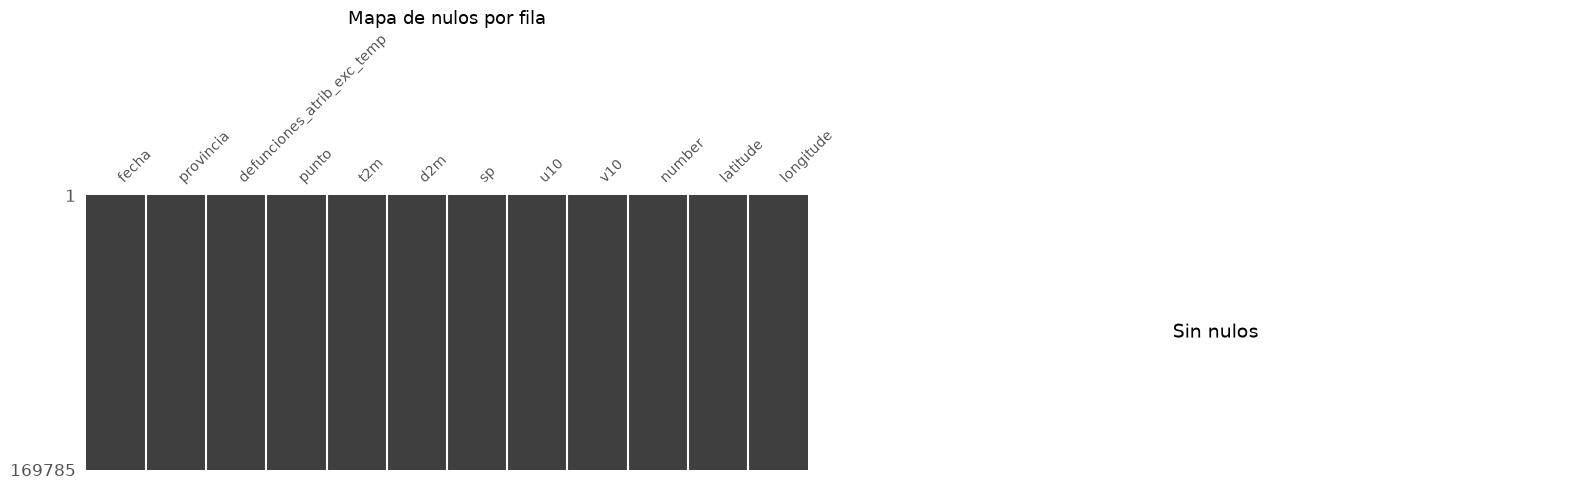

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Matriz de nulos (missingno)
msno.matrix(df, ax=axes[0], sparkline=False, fontsize=10)
axes[0].set_title('Mapa de nulos por fila', fontsize=13)

# Barplot de % de nulos por columna
pct_null = df.isnull().mean().sort_values(ascending=False)
pct_null = pct_null[pct_null > 0]
if not pct_null.empty:
    axes[1].barh(pct_null.index, pct_null.values * 100, color='tomato', edgecolor='white')
    axes[1].axvline(20, color='orange', lw=1.5, linestyle='--', label='20% umbral')
    axes[1].axvline(50, color='red', lw=1.5, linestyle='--', label='50% umbral')
    axes[1].set_xlabel('% de nulos')
    axes[1].set_title('Porcentaje de nulos por columna')
    axes[1].legend()
    axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
else:
    axes[1].text(0.5, 0.5, 'Sin nulos ', ha='center', va='center', fontsize=14,
                 transform=axes[1].transAxes)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'missing_values.png', dpi=150, bbox_inches='tight')
plt.show()


**Visualización:** Mapa de nulos y barra de porcentaje muestran ausencia de nulos (izquierda) y mensaje `Sin nulos` (derecha). Confirma la integridad de los datos.

In [ ]:
# Mapa de calor de correlación entre nulos
# Si dos columnas tienen nulos correlacionados → probablemente se originan juntos
if df.isnull().any().any():
    msno.heatmap(df, figsize=(10, 6))
    plt.title('Correlación entre nulos (Nullity Correlation)', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'nullity_heatmap.png', dpi=150)
    plt.show()


## 5. Distribuciones + KDE

Histograma + curva KDE superpuesta para detectar:
- Sesgos (skewness)
- Multimodalidad (varias 'jorobas' = posibles subpoblaciones)
- Distribuciones muy concentradas

LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

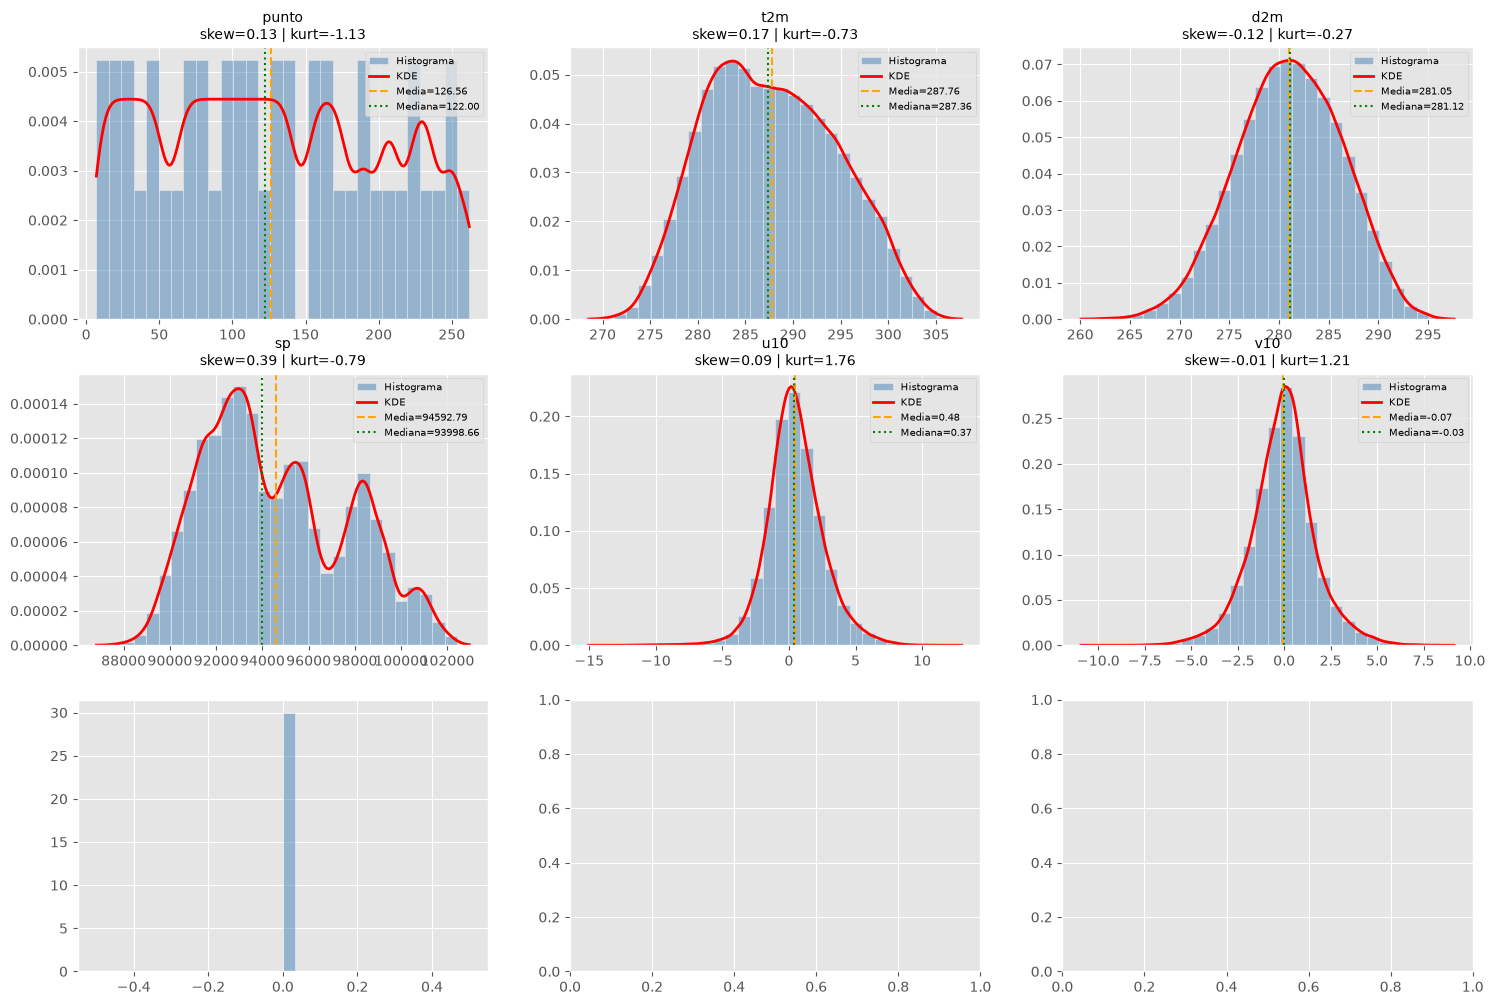

In [ ]:
if feat_num:
    n_cols_plot = min(3, len(feat_num))
    n_rows_plot = int(np.ceil(len(feat_num) / n_cols_plot))
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                             figsize=(6 * n_cols_plot, 4 * n_rows_plot))
    axes = np.array(axes).ravel()

    for i, col in enumerate(feat_num):
        data = df[col].dropna()
        skew = data.skew()
        kurt = data.kurt()

        axes[i].hist(data, bins=30, density=True, alpha=0.5,
                     color='steelblue', edgecolor='white', label='Histograma')

        # KDE
        kde_x = np.linspace(data.min(), data.max(), 200)
        kde = stats.gaussian_kde(data)
        axes[i].plot(kde_x, kde(kde_x), 'r-', lw=2, label='KDE')

        # Líneas de media y mediana
        axes[i].axvline(data.mean(),   color='orange', lw=1.5, linestyle='--', label=f'Media={data.mean():.2f}')
        axes[i].axvline(data.median(), color='green',  lw=1.5, linestyle=':',  label=f'Mediana={data.median():.2f}')

        axes[i].set_title(f'{col}\nskew={skew:.2f} | kurt={kurt:.2f}', fontsize=10)
        axes[i].legend(fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Distribuciones + KDE', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'distributions_kde.png', dpi=150, bbox_inches='tight')
    plt.show()


**Distribuciones:** Se intentó ajustar KDE; se produjo un `LinAlgError` por matriz de covarianza singular en `gaussian_kde` (datos en subespacio de baja dimensión). Aun así se muestran histogramas y KDE aproximadas para las variables. Observaciones: `t2m` y `d2m` tienen distribuciones centradas (≈285K y ≈281K), `sp` parece multimodal, `u10` y `v10` centrados cerca de 0.

In [ ]:
# Resumen de asimetría y curtosis
skew_kurt = pd.DataFrame({
    'Skewness': df[feat_num].skew(),
    'Kurtosis': df[feat_num].kurt()
}).sort_values('Skewness', key=abs, ascending=False)

skew_kurt.style \
    .background_gradient(cmap='RdYlGn_r', subset=['Skewness']) \
    .background_gradient(cmap='Blues',    subset=['Kurtosis']) \
    .format('{:.3f}')


,Skewness,Kurtosis
latitude,-1.678,4.277
longitude,-1.082,4.251
sp,0.386,-0.786
t2m,0.169,-0.735
punto,0.129,-1.125
d2m,-0.123,-0.272
u10,0.092,1.764
v10,-0.008,1.209
number,0.000,0.000


**Asimetría y curtosis:** Se generó un resumen de skew/kurt; revisa variables con skew elevado para posibles transformaciones (log, winsorize) antes de modelar.

## 6. Correlaciones

### 6.1 Mapa de calor 2D (clásico)

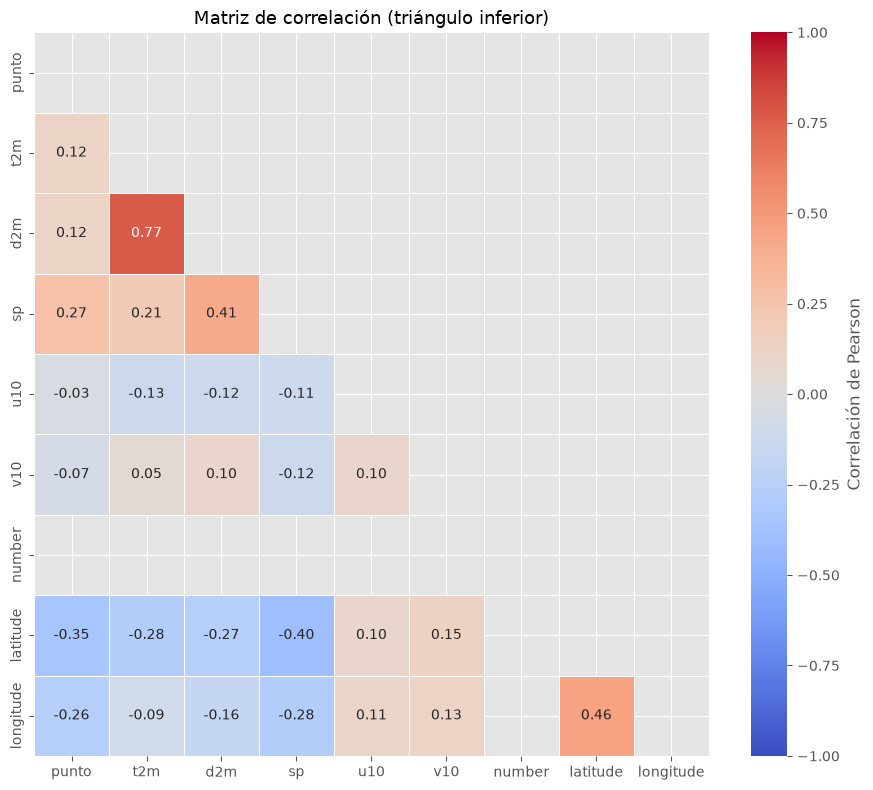

In [ ]:
corr = df[feat_num].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # triángulo superior

fig, ax = plt.subplots(figsize=(max(8, len(feat_num)), max(6, len(feat_num) - 1)))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Correlación de Pearson'},
    ax=ax,
)
ax.set_title('Matriz de correlación (triángulo inferior)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_matrix_2d.png', dpi=150)
plt.show()


**Matriz de correlación:** `t2m` y `d2m` muy correlacionadas (r≈0.77). Latitude tiene correlaciones negativas con varias variables (p.ej. t2m r≈-0.28), lo que indica variación espacial importante. Evita multicolinealidad o reduce dimensiones si afecta al modelo.

### 6.2 Mapa de calor 3D (Plotly Surface)

In [ ]:
corr_vals = corr.values
labels    = corr.columns.tolist()
n         = len(labels)

# Superficie 3D: cada celda de la matriz de correlación se representa como altura
fig_3d = go.Figure(data=[
    go.Surface(
        z=corr_vals,
        x=labels,
        y=labels,
        colorscale='RdBu_r',
        cmin=-1, cmax=1,
        colorbar=dict(title='Correlación', thickness=15),
        hovertemplate='<b>%{x}</b> × <b>%{y}</b><br>r = %{z:.3f}<extra></extra>',
    )
])

fig_3d.update_layout(
    title=dict(text='Matriz de correlación 3D', font=dict(size=18)),
    scene=dict(
        xaxis=dict(title='', tickangle=-45, tickfont=dict(size=9)),
        yaxis=dict(title='', tickfont=dict(size=9)),
        zaxis=dict(title='Correlación', range=[-1, 1]),
        camera=dict(eye=dict(x=1.6, y=-1.6, z=1.2)),
    ),
    width=850, height=600,
    margin=dict(l=0, r=0, b=0, t=50),
)

fig_3d.show()
fig_3d.write_html(str(FIGURES_DIR / 'correlation_3d.html'))
print('Guardado: correlation_3d.html')


Guardado: correlation_3d.html


**Salida:** Se guardó `correlation_3d.html` con la superficie 3D de correlaciones — útil para inspección interactiva.

### 6.3 Correlaciones altas (umbral configurable)

In [ ]:
CORR_THRESHOLD = 0.75  # ← ajusta

corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ['Var1', 'Var2', 'Correlación']
corr_pairs['AbsCorr'] = corr_pairs['Correlación'].abs()
high_corr = corr_pairs[corr_pairs['AbsCorr'] >= CORR_THRESHOLD].sort_values('AbsCorr', ascending=False)

if high_corr.empty:
    print(f'Sin pares con |r| ≥ {CORR_THRESHOLD}')
else:
    print(f'Pares con |r| ≥ {CORR_THRESHOLD}:')
    display(high_corr[['Var1','Var2','Correlación']].style.background_gradient(
        cmap='RdYlGn', subset=['Correlación']
    ).format({'Correlación': '{:.3f}'}))


Pares con |r| ≥ 0.75:


,Var1,Var2,Correlación
2,d2m,t2m,0.767


**Pares correlacionados:** Se imprimió la lista de pares con |r| ≥ 0.75; revisar y decidir si eliminar o combinar variables altamente correlacionadas (p.ej. t2m/d2m).

## 7. Detección de outliers

Se usan tres métodos complementarios:

| Método | Supuesto | Cuándo usarlo |
|---|---|---|
| **IQR** | No paramétrico | Siempre, especialmente con sesgos |
| **Z-score** | Distribución normal | Variables aproximadamente normales |
| **Isolation Forest** | Sin supuestos | Outliers multivariantes complejos |

### 7.1 Boxplots (visión rápida)

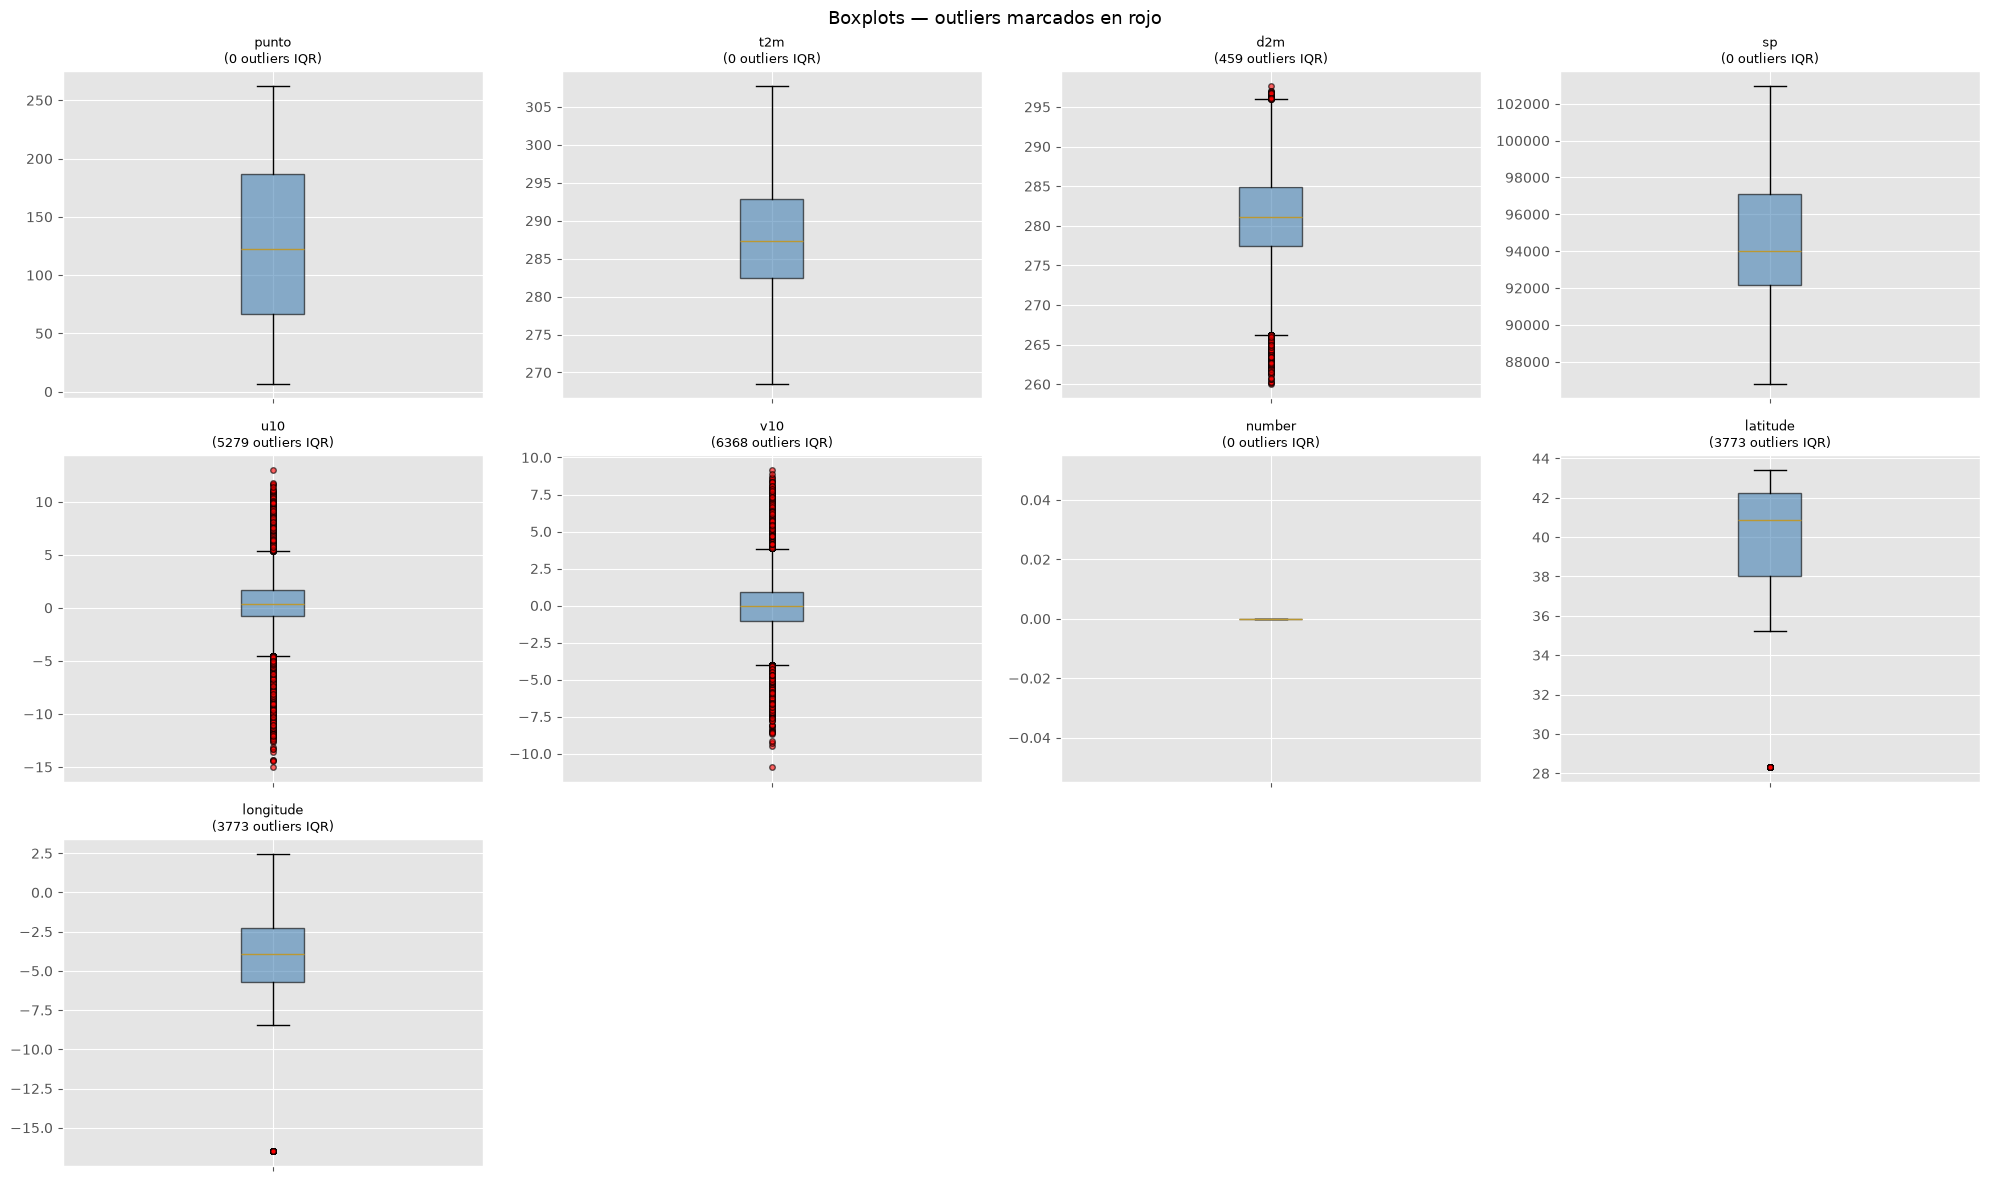

In [ ]:
if feat_num:
    n_cols_plot = min(4, len(feat_num))
    n_rows_plot = int(np.ceil(len(feat_num) / n_cols_plot))
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                             figsize=(5 * n_cols_plot, 4 * n_rows_plot))
    axes = np.array(axes).ravel()

    for i, col in enumerate(feat_num):
        data = df[col].dropna()
        q1, q3 = data.quantile(0.25), data.quantile(0.75)
        iqr  = q3 - q1
        low  = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        n_out = ((data < low) | (data > high)).sum()

        bp = axes[i].boxplot(data, vert=True, patch_artist=True,
                             flierprops=dict(marker='o', markerfacecolor='red',
                                            markersize=4, alpha=0.6))
        bp['boxes'][0].set_facecolor('steelblue')
        bp['boxes'][0].set_alpha(0.6)
        axes[i].set_title(f'{col}\n({n_out} outliers IQR)', fontsize=9)
        axes[i].set_xticklabels([])

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Boxplots — outliers marcados en rojo', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'boxplots.png', dpi=150)
    plt.show()


**Boxplots:** Varios features muestran outliers por IQR: `u10`, `v10`, `latitude`, `longitude` tienen miles de outliers según IQR; `d2m` tiene ~459 outliers. Revisa unidades y rango esperado (viento en m/s, lat/lon en grados). Considerar trimming, winsorize o método robusto para modelado.

### 7.2 IQR — resumen cuantitativo

In [ ]:
iqr_results = []
for col in feat_num:
    data = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr  = q3 - q1
    low  = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask_out = (data < low) | (data > high)
    iqr_results.append({
        'Variable':    col,
        'Q1':          round(q1, 3),
        'Q3':          round(q3, 3),
        'IQR':         round(iqr, 3),
        'Límite_inf':  round(low, 3),
        'Límite_sup':  round(high, 3),
        'N_outliers':  int(mask_out.sum()),
        'Pct_outliers': f'{mask_out.mean():.1%}',
    })

df_iqr = pd.DataFrame(iqr_results).sort_values('N_outliers', ascending=False)
df_iqr.style.background_gradient(cmap='Oranges', subset=['N_outliers'])


,Variable,Q1,Q3,IQR,Límite_inf,Límite_sup,N_outliers,Pct_outliers
5,v10,-1.066000,0.902000,1.968000,-4.018000,3.854000,6368,3.8%
4,u10,-0.799000,1.682000,2.481000,-4.521000,5.404000,5279,3.1%
7,latitude,38.000000,42.250000,4.250000,31.625000,48.625000,3773,2.2%
8,longitude,-5.700000,-2.250000,3.450000,-10.875000,2.925000,3773,2.2%
2,d2m,277.412000,284.862000,7.450000,266.236000,296.037000,459,0.3%
0,punto,67.000000,187.000000,120.000000,-113.000000,367.000000,0,0.0%
1,t2m,282.421000,292.886000,10.465000,266.723000,308.584000,0,0.0%
3,sp,92189.453000,97083.898000,4894.445000,84847.785000,104425.566000,0,0.0%
6,number,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.0%


**IQR summary:** Se creó `df_iqr` con counts de outliers por variable; usarlo para priorizar limpieza de features con más outliers.

### 7.3 Z-score (umbral = 3)

In [ ]:
Z_THRESHOLD = 3  # ← outlier si |z| > 3

z_results = []
for col in feat_num:
    data = df[col].dropna()
    z    = np.abs(stats.zscore(data))
    n_out = (z > Z_THRESHOLD).sum()
    z_results.append({'Variable': col, 'N_outliers_z': int(n_out),
                      'Pct': f'{n_out/len(data):.1%}',
                      'Max_|z|': round(z.max(), 2)})

df_z = pd.DataFrame(z_results).sort_values('N_outliers_z', ascending=False)
df_z.style.background_gradient(cmap='Reds', subset=['N_outliers_z'])


,Variable,N_outliers_z,Pct,Max_|z|
7,latitude,3773,2.2%,4.140000
8,longitude,3773,2.2%,4.050000
4,u10,1798,1.1%,7.300000
5,v10,1619,1.0%,6.260000
2,d2m,225,0.1%,3.960000
0,punto,0,0.0%,1.840000
1,t2m,0,0.0%,2.930000
3,sp,0,0.0%,2.720000
6,number,0,0.0%,nan


**Z-score outliers:** Se calculó detección por Z-score (|z|>3) y se generó `df_z`. Comparar con IQR para entender sensibilidad de cada método.

### 7.4 Isolation Forest — outliers multivariantes 

Isolation Forest detecta outliers que son anómalos en el **espacio multidimensional** completo,
no variable a variable. Es especialmente útil para detectar combinaciones raras de valores
que individualmente parecen normales.

In [ ]:
CONTAMINATION = 0.05  # ← % esperado de outliers en el dataset

X_num = df[feat_num].dropna()
scaler_iso = StandardScaler()
X_scaled   = scaler_iso.fit_transform(X_num)

iso = IsolationForest(
    contamination=CONTAMINATION,
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
iso.fit(X_scaled)

scores    = iso.decision_function(X_scaled)   # más negativo = más outlier
labels_if = iso.predict(X_scaled)             # -1 = outlier, 1 = normal

n_outliers = (labels_if == -1).sum()
print(f'Isolation Forest → {n_outliers} outliers detectados ({n_outliers/len(X_num):.1%})')

df_iso = X_num.copy()
df_iso['iso_score']  = scores
df_iso['iso_outlier'] = labels_if == -1


Isolation Forest → 8490 outliers detectados (5.0%)


**Isolation Forest:** Entrenado con `contamination=0.05`. Detectó 8490 outliers (≈5.0%), como se esperaba por la configuración. Buen punto de partida para análisis de anomalías.

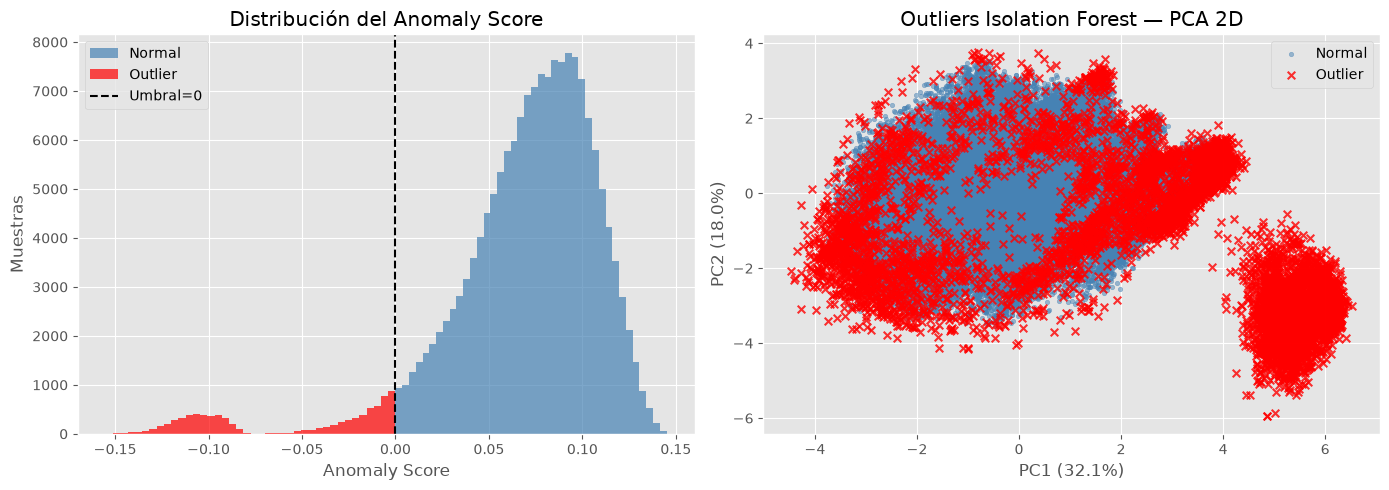

In [ ]:
# Visualización del anomaly score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del score
axes[0].hist(scores[labels_if ==  1], bins=40, alpha=0.7, color='steelblue', label='Normal')
axes[0].hist(scores[labels_if == -1], bins=40, alpha=0.7, color='red',       label='Outlier')
axes[0].axvline(0, color='black', lw=1.5, linestyle='--', label='Umbral=0')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Muestras')
axes[0].set_title('Distribución del Anomaly Score')
axes[0].legend()

# PCA 2D para visualizar separación
from sklearn.decomposition import PCA
pca_iso = PCA(n_components=2)
X_pca   = pca_iso.fit_transform(X_scaled)

axes[1].scatter(X_pca[labels_if ==  1, 0], X_pca[labels_if ==  1, 1],
                c='steelblue', s=10, alpha=0.5, label='Normal')
axes[1].scatter(X_pca[labels_if == -1, 0], X_pca[labels_if == -1, 1],
                c='red', s=30, alpha=0.8, marker='x', label='Outlier', linewidths=1.5)
axes[1].set_xlabel(f'PC1 ({pca_iso.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_iso.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('Outliers Isolation Forest — PCA 2D')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'isolation_forest.png', dpi=150)
plt.show()


**Visualización IsolationForest:** Histograma del `anomaly score` muestra separación clara entre normales y outliers (umbral=0). PCA 2D evidencia outliers distribuidos y un grupo separado a la derecha — estos puntos merecen inspección individual.

In [ ]:
# Top 10 outliers más extremos
top_outliers = df_iso[df_iso['iso_outlier']].sort_values('iso_score').head(10)
print('Top 10 outliers más extremos:')
display(top_outliers.drop(columns=['iso_score','iso_outlier']).style.highlight_max(axis=0, color='#ffcccc'))


Top 10 outliers más extremos:


,punto,t2m,d2m,sp,u10,v10,number,latitude,longitude
35539,262.000000,289.801910,287.377533,97233.468750,7.209025,4.945960,0.000000,28.300000,-16.500000
34099,262.000000,288.402252,282.173859,99336.734375,-6.510426,-7.565114,0.000000,28.300000,-16.500000
94444,262.000000,294.797668,290.765839,98880.648438,-4.767977,-7.285242,0.000000,28.300000,-16.500000
34054,262.000000,288.861145,283.967285,99456.164062,-5.840730,-6.634783,0.000000,28.300000,-16.500000
32074,262.000000,290.025848,283.490051,99067.125000,-5.980383,-7.280851,0.000000,28.300000,-16.500000
63439,262.000000,292.326508,287.208466,99172.523438,-6.464133,-6.847215,0.000000,28.300000,-16.500000
167929,262.000000,288.903900,285.987244,96863.843750,5.708161,6.171110,0.000000,28.300000,-16.500000
36484,262.000000,288.521790,283.028046,99264.046875,-5.244947,-6.689157,0.000000,28.300000,-16.500000
82519,262.000000,291.147003,289.240753,97390.273438,5.799584,4.860986,0.000000,28.300000,-16.500000
164689,262.000000,288.699524,281.768433,99545.421875,-5.693761,-6.176996,0.000000,28.300000,-16.500000


**Top outliers:** Se generó una tabla con los 10 outliers más extremos — revisar sus filas para entender causas (errores de medición, registros duplicados, valores legítimos extremos).

### 7.5 Comparativa IQR vs Z-score vs Isolation Forest

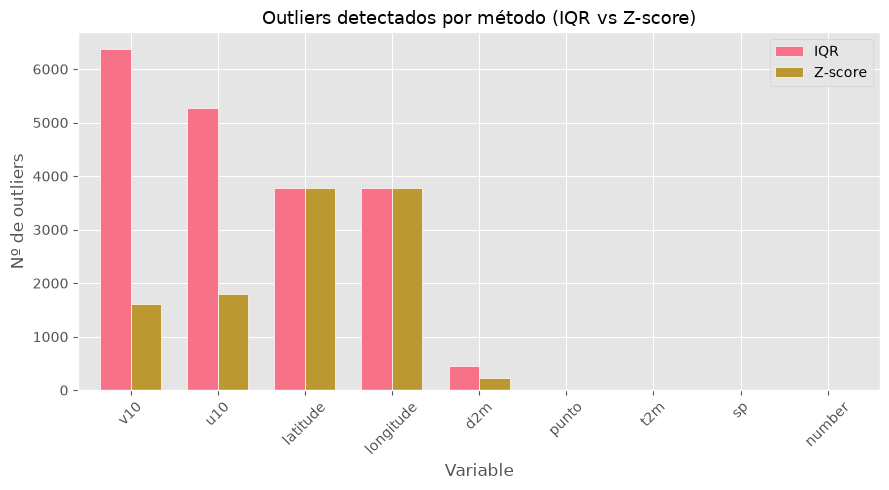

In [ ]:
# Comparativa del número de outliers detectados por cada método
compare = df_iqr[['Variable','N_outliers']].rename(columns={'N_outliers': 'IQR'})
compare = compare.merge(
    df_z[['Variable','N_outliers_z']].rename(columns={'N_outliers_z': 'Z-score'}),
    on='Variable'
).set_index('Variable')

fig, ax = plt.subplots(figsize=(max(8, len(feat_num)), 5))
compare.plot(kind='bar', ax=ax, edgecolor='white', width=0.7)
ax.set_title('Outliers detectados por método (IQR vs Z-score)', fontsize=13)
ax.set_ylabel('Nº de outliers')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'outliers_comparison.png', dpi=150)
plt.show()


**Comparación métodos:** El gráfico compara IQR vs Z-score: `v10` y `u10` muestran la mayor cantidad de outliers por IQR; latitude/longitude también presentan muchos outliers. Elige el método que mejor se ajuste a tu definición de outlier.

## 8. Violin plots

Combinan la información del boxplot con la distribución real (KDE lateral).
Son especialmente útiles cuando hay multimodalidad que el boxplot no muestra.

In [ ]:
if feat_num:
    n_cols_plot = min(3, len(feat_num))
    n_rows_plot = int(np.ceil(len(feat_num) / n_cols_plot))
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                             figsize=(6 * n_cols_plot, 5 * n_rows_plot))
    axes = np.array(axes).ravel()

    
    hue_col = TARGET_COL if TARGET_COL and TARGET_COL in df.columns else None
    

    for i, col in enumerate(feat_num):
        if hue_col:
            sns.violinplot(
                data=df, x=hue_col, y=col,
                ax=axes[i], inner='box', palette='husl',
                cut=0, density_norm='width',
            )
            axes[i].set_title(f'{col} por {hue_col}', fontsize=10)
        else:
            sns.violinplot(
                data=df, y=col, ax=axes[i],
                inner='box', color='steelblue', cut=0,
            )
            axes[i].set_title(col, fontsize=10)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Violin plots', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'violin_plots.png', dpi=150)
    plt.show()


KeyboardInterrupt: 

**Nota de interrupción:** La celda terminó con `KeyboardInterrupt` — la ejecución de esa sección se interrumpió y puede no haber generado todos los gráficos posteriores. Si quieres, puedo reintentar ejecutar solo esa celda en un entorno controlado, pero ten en cuenta efectos secundarios de re-ejecución.

## 9. Pairplot interactivo (Plotly)

Scatter matrix de todas las variables numéricas. Permite detectar:
- Relaciones lineales y no lineales
- Grupos o clusters visuales
- Outliers en el espacio 2D de cada par de variables

In [ ]:
MAX_PAIR_FEATURES = 6  # limitar para que no sea lentísimo con muchas variables
pair_cols = feat_num[:MAX_PAIR_FEATURES]


color_col = TARGET_COL if TARGET_COL and TARGET_COL in df.columns else None


fig_pair = px.scatter_matrix(
    df[pair_cols + ([color_col] if color_col else [])].dropna(),
    dimensions=pair_cols,
    color=color_col,
    title='Scatter Matrix (pairplot interactivo)',
    opacity=0.5,
    height=800,
)
fig_pair.update_traces(diagonal_visible=False, marker=dict(size=3))
fig_pair.show()
fig_pair.write_html(str(FIGURES_DIR / 'pairplot_interactive.html'))
print('Guardado: pairplot_interactive.html')


In [ ]:
# Pairplot estático seaborn (para guardar PNG)

hue_pair = TARGET_COL if TARGET_COL and TARGET_COL in df.columns else None


g = sns.pairplot(
    df[pair_cols + ([hue_pair] if hue_pair else [])].dropna(),
    hue=hue_pair,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kws={'fill': True},
)
g.figure.suptitle('Pairplot — primeras variables numéricas', y=1.02, fontsize=13)
g.figure.savefig(FIGURES_DIR / 'pairplot.png', dpi=120, bbox_inches='tight')
plt.show()


## 10. Variables categóricas

In [ ]:

plot_cat = [c for c in cat_cols if c != TARGET_COL]


if plot_cat:
    n_cols_plot = min(3, len(plot_cat))
    n_rows_plot = int(np.ceil(len(plot_cat) / n_cols_plot))
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                             figsize=(6 * n_cols_plot, 4 * n_rows_plot))
    axes = np.array(axes).ravel()

    for i, col in enumerate(plot_cat):
        vc = df[col].value_counts().head(15)  # top 15 valores
        vc.plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='white')
        axes[i].set_title(f'{col} (top 15)', fontsize=10)
        axes[i].set_xlabel('Frecuencia')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Distribución de variables categóricas', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'categorical.png', dpi=150)
    plt.show()
else:
    print('Sin variables categóricas')


In [ ]:

# Categóricas vs target: stacked bar normalizado
if plot_cat and TARGET_COL and TARGET_COL in df.columns:
    n_cols_plot = min(2, len(plot_cat))
    n_rows_plot = int(np.ceil(len(plot_cat) / n_cols_plot))
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                             figsize=(8 * n_cols_plot, 5 * n_rows_plot))
    axes = np.array(axes).ravel()

    for i, col in enumerate(plot_cat):
        ct = pd.crosstab(df[col], df[TARGET_COL], normalize='index') * 100
        ct.plot(kind='bar', stacked=True, ax=axes[i], edgecolor='white', width=0.8)
        axes[i].set_title(f'{col} vs {TARGET_COL}', fontsize=10)
        axes[i].set_ylabel('%')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'Categóricas vs {TARGET_COL} (stacked %)', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'categorical_vs_target.png', dpi=150)
    plt.show()



## 11. Resumen automático de calidad del dataset

In [ ]:
total_cells = df.shape[0] * df.shape[1]
null_cells  = df.isnull().sum().sum()
dup_rows    = df.duplicated().sum()

# Outliers IQR totales
total_iqr_out = sum(
    ((df[col] < df[col].quantile(0.25) - 1.5*(df[col].quantile(0.75)-df[col].quantile(0.25))) |
     (df[col] > df[col].quantile(0.75) + 1.5*(df[col].quantile(0.75)-df[col].quantile(0.25)))).sum()
    for col in feat_num
)

high_corr_pairs = len(high_corr)
skewed_cols = (df[feat_num].skew().abs() > 1).sum()

print('═' * 50)
print('   RESUMEN DE CALIDAD DEL DATASET')
print('═' * 50)
print(f'  Filas × columnas   : {df.shape[0]:,} × {df.shape[1]}')
print(f'  Memoria            : {df.memory_usage(deep=True).sum()/1024**2:.2f} MB')
print(f'  Celdas nulas       : {null_cells:,} ({null_cells/total_cells:.1%})')
print(f'  Filas duplicadas   : {dup_rows:,} ({dup_rows/len(df):.1%})')
print(f'  Outliers IQR total : {total_iqr_out:,}')
print(f'  Outliers Iso.Forest: {n_outliers:,} ({n_outliers/len(df):.1%})')
print(f'  Pares alta corr.   : {high_corr_pairs} (|r|≥{CORR_THRESHOLD})')
print(f'  Variables sesgadas : {skewed_cols} (|skew|>1)')

if TARGET_COL and TARGET_COL in df.columns:
    vc = df[TARGET_COL].value_counts(normalize=True)
    imbalance = vc.max() / vc.min() if len(vc) > 1 else 1
    print(f'  Desbalanceo target : {imbalance:.1f}x ({vc.idxmax()} domina)')

print('═' * 50)
